# Eye Tracking benchmark: 3. Confirmatory nested LODO evaluation

This is the sole performance-estimation stage for the adaptive selector. Each outer fold holds out one complete dataset, evaluates its eligible artificial gaps once, and reports an unweighted macro mean across held-out datasets.


## Leakage controls and nested tuning

For a held-out dataset, hyperparameters are selected only in inner LODO folds among the remaining datasets. The local-IQR scale floor is also estimated from the relevant training fold only. Features use observable local context; the artificial gap's truth is never used as a predictor.

This grouping prevents a held-out dataset from influencing model fitting, tuning, or scale estimation for its outer-fold predictions.


## Pre-specified comparators and interpretation

The selector predicts the candidate-method nRMSE values and selects the method with the lowest predicted error. It is compared with fixed PCHIP and the offline oracle; where included in the result table, the best single fixed method is also reported. The oracle is an unattainable lower bound because it selects after the concealed truth is revealed.

The primary metric is mean held-out nRMSE; lower is better. Comparisons with PCHIP are paired within the same held-out gaps, so a positive improvement favours the selector.


In [1]:
from pathlib import Path
import os
import subprocess
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / 'pyproject.toml').is_file():
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise RuntimeError('Start Jupyter from inside the repository.')
    PROJECT_ROOT = PROJECT_ROOT.parent

# Read ignored workstation paths without placing them in this notebook.
source_root = str(PROJECT_ROOT / 'src')
if source_root not in sys.path:
    sys.path.insert(0, source_root)
from gap_imputation_benchmark.domains.eyetracking import EYE_TRACKING_DOMAIN
from gap_imputation_benchmark.evaluation import (
    plot_macro_lodo_comparison,
    plot_selected_method_frequency,
)
from gap_imputation_benchmark.paths import load_local_environment, local_path_or_default
# The local .env file is authoritative for this workstation notebook.
load_local_environment(override=True)

BENCHMARK_DIR = local_path_or_default(
    'EYE_TRACKING_BENCHMARK_DIR', PROJECT_ROOT / 'benchmarks' / 'eyetracking',
)
RESULTS_DIR = local_path_or_default(
    'EYE_TRACKING_LODO_RESULTS_DIR', PROJECT_ROOT / 'results' / 'eyetracking' / 'lodo',
)
SCRIPT = PROJECT_ROOT / 'scripts' / 'evaluate_eye_tracking_lodo.py'
# Run directly from src/ so the notebook works before an editable package install.
execution_env = os.environ.copy()
execution_env['PYTHONPATH'] = source_root + os.pathsep + execution_env.get('PYTHONPATH', '')
command = [sys.executable, str(SCRIPT), '--benchmark-dir', str(BENCHMARK_DIR), '--results-dir', str(RESULTS_DIR)]
subprocess.run(command, cwd=PROJECT_ROOT, env=execution_env, check=True)
try:
    output_location = RESULTS_DIR.relative_to(PROJECT_ROOT).as_posix()
except ValueError:
    output_location = 'configured evaluation directory'
print(f'LODO evaluation outputs: {output_location}')

            evaluation_set  n_gaps  mean_selected_nrmse  mean_pchip_nrmse  mean_oracle_nrmse  absolute_improvement_vs_pchip_nrmse  mean_regret_vs_oracle_nrmse  oracle_match_rate  relative_improvement_vs_pchip_percent
                  GazeBase     400             0.179165          0.179106           0.143987                            -0.000060                     0.035178           0.210000                              -0.033387
                GazeBaseVR     400             0.164256          0.165305           0.129807                             0.001049                     0.034449           0.287500                               0.634412
                  Pedrotti     399             0.381700          0.381810           0.313093                             0.000110                     0.068606           0.152882                               0.028746
                      ZuCo     400             0.160115          0.160343           0.126142                             0.000228   

## Run the frozen evaluation

The canonical command reads the benchmark, frozen configuration, and any required external data. It writes one self-contained results directory and does not silently replace reviewed outputs. Use a new configured results path for an intentional rerun.


In [2]:
summary = pd.read_csv(RESULTS_DIR / 'lodo_summary.csv')
tuning = pd.read_csv(RESULTS_DIR / 'lodo_hyperparameter_tuning.csv')
display(summary)
display(tuning.groupby('outer_target_dataset', group_keys=False).head(1))

,evaluation_set,n_gaps,mean_selected_nrmse,mean_pchip_nrmse,mean_oracle_nrmse,absolute_improvement_vs_pchip_nrmse,mean_regret_vs_oracle_nrmse,oracle_match_rate,relative_improvement_vs_pchip_percent
0,GazeBase,400,0.179165,0.179106,0.143987,-0.000060,0.035178,0.210000,-0.033387
1,GazeBaseVR,400,0.164256,0.165305,0.129807,0.001049,0.034449,0.287500,0.634412
2,Pedrotti,399,0.381700,0.381810,0.313093,0.000110,0.068606,0.152882,0.028746
3,ZuCo,400,0.160115,0.160343,0.126142,0.000228,0.033972,0.225000,0.142441
4,macro_mean_across_datasets,1599,0.221309,0.221641,0.178257,0.000332,0.043052,0.218846,0.149687


,outer_target_dataset,candidate_index,n_estimators,min_samples_leaf,max_depth,max_features,inner_lodo_macro_mean_selected_nrmse,inner_validation_GazeBaseVR_mean_selected_nrmse,inner_validation_Pedrotti_mean_selected_nrmse,inner_validation_ZuCo_mean_selected_nrmse,inner_validation_GazeBase_mean_selected_nrmse
0,GazeBase,1,400,5,NaN,sqrt,0.235782,0.165300,0.381615,0.160431,NaN
7,GazeBaseVR,1,400,5,NaN,sqrt,0.240404,NaN,0.381546,0.160596,0.179071
14,Pedrotti,7,500,10,12.0,0.7,0.167474,0.164233,NaN,0.159373,0.178816
21,ZuCo,5,300,5,12.0,0.7,0.241491,0.164798,0.382061,NaN,0.177615


## Outer-fold results and inner-fold tuning record

`lodo_summary.csv` contains one row per held-out dataset plus the unweighted macro mean. `lodo_hyperparameter_tuning.csv` documents candidate scores within each outer fold, making the selected configuration auditable.

The prediction table should contain one row per eligible held-out gap. Any difference from the requested benchmark count must be traced to explicit method-applicability or exclusion records before aggregate results are interpreted.


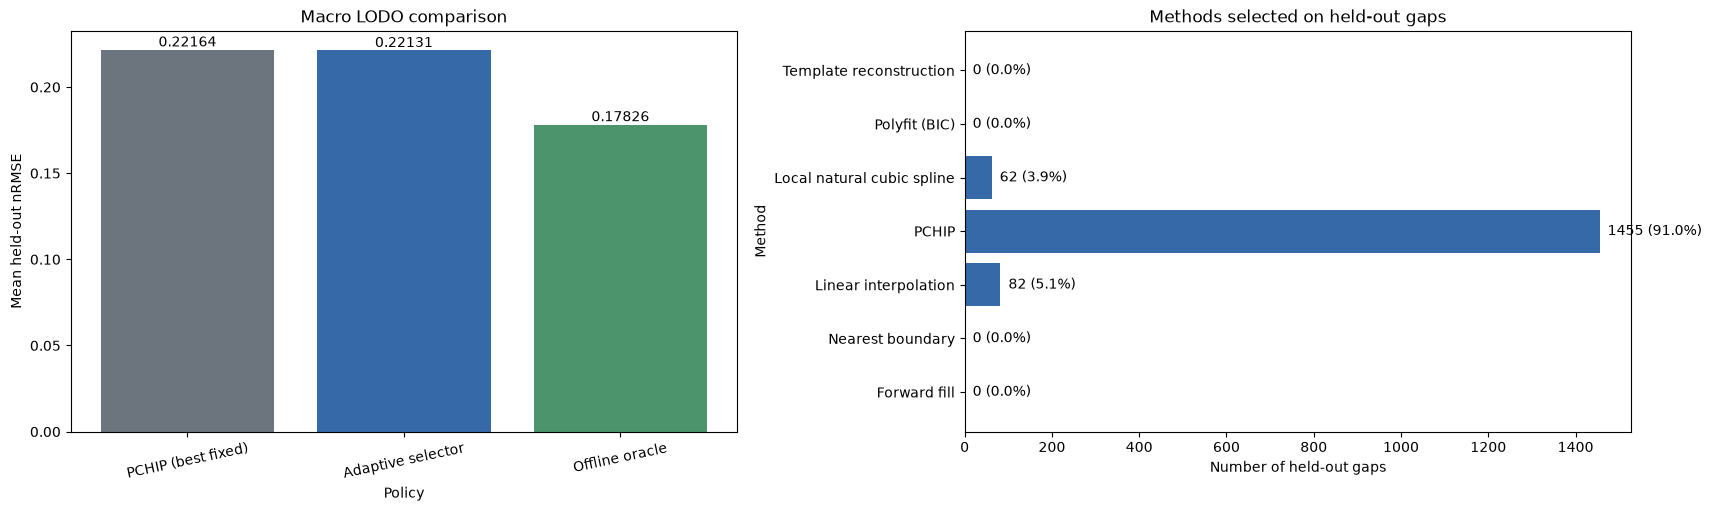

,mean_nrmse
PCHIP (best fixed),0.22164
Adaptive selector,0.22131
Offline oracle,0.17826


,count,share
selected_method,,
forward_fill,0,0.0
nearest_boundary,0,0.0
linear,8200,5.1
pchip,145500,91.0
local_natural_cubic_spline,6200,3.9
polyfit_bic,0,0.0
template,0,0.0


In [3]:
selected_method_counts = pd.read_csv(RESULTS_DIR / 'lodo_selected_method_counts.csv')

fig, axes = plt.subplots(1, 2, figsize=(17, 5), constrained_layout=True)
_, macro_comparison = plot_macro_lodo_comparison(
    summary,
    metric_columns={
        'PCHIP (best fixed)': 'mean_pchip_nrmse',
        'Adaptive selector': 'mean_selected_nrmse',
        'Offline oracle': 'mean_oracle_nrmse',
    },
    ax=axes[0],
)
_, selected_method_summary = plot_selected_method_frequency(
    selected_method_counts,
    EYE_TRACKING_DOMAIN.methods,
    method_labels=EYE_TRACKING_DOMAIN.method_labels,
    ax=axes[1],
)
plt.show()

display(macro_comparison.rename('mean_nrmse').to_frame().round(5))
display((100 * selected_method_summary).round(1))

## Macro comparison and method-selection behaviour

The macro comparison gives every held-out dataset equal weight; it does not pool units by their number of gaps. The selected-method panel summarises only held-out predictions. Selection frequency is a behavioural diagnostic, not evidence of superiority on its own.

Together with the per-fold table, these outputs support review of both aggregate performance and heterogeneity across datasets.
